# Montana Cities Transportation and Walkability Analysis

This notebook analyzes data on transportation emissions and walkability in Montana cities. The goal is to explore relationships between vehicle usage, greenhouse gas emissions, and walkability indices.

## Dataset Overview
- **full_city_data_DATA603.csv**: Aggregated city-level data including population, housing, miles driven, fuel consumption, emissions, and walkability metrics.
- **city_blockgroup_pairs_DATA603.csv**: Mapping between cities and census block groups.
- **Cleaned versions**: Processed data with invalid values handled.

## Objectives
1. Load and clean the data
2. Perform exploratory data analysis
3. Visualize key metrics
4. Analyze correlations between emissions and walkability
5. Identify cities with high emissions and low walkability

## 1. Install and Import Dependencies

If running on Google Colab, uncomment the installation lines if needed.

In [1]:
# Install dependencies (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn plotly

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

Load the main dataset and examine its structure.

In [12]:
# Load the cleaned full city data
df = pd.read_csv('cleaned_full_city_data.csv')

# Filter to Montana cities only
df = df[df['state_abbr'] == 'MT']

# Display basic info
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (129, 29)

Columns:
['NAME', 'NAMELSAD', 'state_abbr', 'city_id', 'city_state_name', 'population', 'house_units', 'miles_driven_pC', 'agg_vehi_consum_pC', 'gasoline_consume_pC', 'diesel_consume_pC', 'agg_vehi_emitGHG_pC', 'agg_nonvehi_emitGHG_pC', 'agg_combined_emitGHG_pC', 'driveGasoline_emitGHG_pC', 'driveDiesel_emitGHG_pC', 'wlk_NatWalkInd_avg', 'wlk_PeopleCounted', 'wlk_Workers', 'wlk_CountHU', 'wlk_HH', 'wlk_D2A_EPHHM_avg', 'wlk_D2B_E8MIXA_avg', 'wlk_D3B_avg', 'wlk_D4A_avg', 'wlk_D2A_Ranked_avg', 'wlk_D2B_Ranked_avg', 'wlk_D3B_Ranked_avg', 'wlk_D4A_Ranked_avg']

First 5 rows:


,NAME,NAMELSAD,state_abbr,city_id,city_state_name,population,house_units,miles_driven_pC,agg_vehi_consum_pC,gasoline_consume_pC,...,wlk_CountHU,wlk_HH,wlk_D2A_EPHHM_avg,wlk_D2B_E8MIXA_avg,wlk_D3B_avg,wlk_D4A_avg,wlk_D2A_Ranked_avg,wlk_D2B_Ranked_avg,wlk_D3B_Ranked_avg,wlk_D4A_Ranked_avg
0,Anaconda-Deer Lodge County,Anaconda-Deer Lodge County,MT,3001675,"Anaconda-Deer Lodge County, MT",9099.999997,3889.000000,19583.128378,1066.100480,871.125000,...,5191.999999,3854.999999,0.525283,0.478452,119.855775,NaN,11.165275,8.681099,9.605824,1.0
1,Jordan,Jordan town,MT,3039925,"Jordan town, MT",0.082113,109.101896,2759.615132,146.500000,123.625000,...,0.059444,0.032169,0.698278,0.922619,0.166795,NaN,16.000000,20.000000,1.000000,1.0
2,Ismay,Ismay town,MT,3038950,"Ismay town, MT",0.296490,11.198711,31100.909091,1604.545455,1314.727273,...,0.146681,0.122912,0.707614,0.688671,0.121447,NaN,16.000000,15.000000,1.000000,1.0
3,Miles City,Miles City city,MT,3049525,"Miles City city, MT",6178.988294,3515.419484,2692.641514,143.929272,122.776739,...,3036.338181,2660.815581,0.588661,0.598753,178.278066,NaN,13.119073,12.324063,17.086184,1.0
4,Bearcreek,Bearcreek town,MT,3004300,"Bearcreek town, MT",0.191179,40.327067,3739.546667,189.893333,172.806667,...,0.099890,0.081091,0.395816,0.700650,0.322301,NaN,7.000000,15.000000,1.000000,1.0


In [13]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Data types:
NAME                         object
NAMELSAD                     object
state_abbr                   object
city_id                       int64
city_state_name              object
population                  float64
house_units                 float64
miles_driven_pC             float64
agg_vehi_consum_pC          float64
gasoline_consume_pC         float64
diesel_consume_pC           float64
agg_vehi_emitGHG_pC         float64
agg_nonvehi_emitGHG_pC      float64
agg_combined_emitGHG_pC     float64
driveGasoline_emitGHG_pC    float64
driveDiesel_emitGHG_pC      float64
wlk_NatWalkInd_avg          float64
wlk_PeopleCounted           float64
wlk_Workers                 float64
wlk_CountHU                 float64
wlk_HH                      float64
wlk_D2A_EPHHM_avg           float64
wlk_D2B_E8MIXA_avg          float64
wlk_D3B_avg                 float64
wlk_D4A_avg                 float64
wlk_D2A_Ranked_avg          float64
wlk_D2B_Ranked_avg          float64
wlk_D3B_Ranked_a

## 3. Data Cleaning

Handle any remaining invalid values and prepare data for analysis.

In [14]:
# Replace empty strings and invalid values with NaN
df = df.replace('', np.nan)
df = df.replace(-99999, np.nan)
df = df.replace(-99998, np.nan)

# Convert numeric columns
numeric_cols = ['population', 'house_units', 'miles_driven_pC', 'agg_vehi_consum_pC', 
                'gasoline_consume_pC', 'diesel_consume_pC', 'agg_vehi_emitGHG_pC',
                'agg_nonvehi_emitGHG_pC', 'agg_combined_emitGHG_pC', 'driveGasoline_emitGHG_pC',
                'driveDiesel_emitGHG_pC', 'wlk_NatWalkInd_avg', 'wlk_PeopleCounted',
                'wlk_Workers', 'wlk_CountHU', 'wlk_HH', 'wlk_D2A_EPHHM_avg',
                'wlk_D2B_E8MIXA_avg', 'wlk_D3B_avg', 'wlk_D4A_avg', 'wlk_D2A_Ranked_avg',
                'wlk_D2B_Ranked_avg', 'wlk_D3B_Ranked_avg', 'wlk_D4A_Ranked_avg']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data cleaning completed.")
print("Missing values after cleaning:")
print(df.isnull().sum())

Data cleaning completed.
Missing values after cleaning:
NAME                          0
NAMELSAD                      0
state_abbr                    0
city_id                       0
city_state_name               0
population                    0
house_units                   0
miles_driven_pC               0
agg_vehi_consum_pC            0
gasoline_consume_pC           0
diesel_consume_pC             0
agg_vehi_emitGHG_pC           0
agg_nonvehi_emitGHG_pC        0
agg_combined_emitGHG_pC       0
driveGasoline_emitGHG_pC      0
driveDiesel_emitGHG_pC        0
wlk_NatWalkInd_avg            0
wlk_PeopleCounted             0
wlk_Workers                   0
wlk_CountHU                   0
wlk_HH                        0
wlk_D2A_EPHHM_avg             0
wlk_D2B_E8MIXA_avg            0
wlk_D3B_avg                   0
wlk_D4A_avg                 121
wlk_D2A_Ranked_avg            0
wlk_D2B_Ranked_avg            0
wlk_D3B_Ranked_avg            0
wlk_D4A_Ranked_avg            0
dtype: int64


## 4. Exploratory Data Analysis

Explore the distributions and basic statistics of key variables.

In [15]:
# Basic statistics
print("Basic statistics for key variables:")
key_vars = ['population', 'miles_driven_pC', 'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg']
df[key_vars].describe()

Basic statistics for key variables:


,population,miles_driven_pC,agg_combined_emitGHG_pC,wlk_NatWalkInd_avg
count,129.000000,129.000000,129.000000,129.000000
mean,3241.905210,4642.047926,8.545888,7.613284
std,11967.423517,5093.638636,5.660131,2.581327
min,0.027895,1328.607843,2.049461,2.166667
25%,0.869310,2415.452302,5.566777,5.666667
50%,48.345089,3403.808318,6.813124,7.333333
75%,1169.741442,4816.357661,9.539938,9.325084
max,95445.470466,44023.653846,47.900115,15.545409


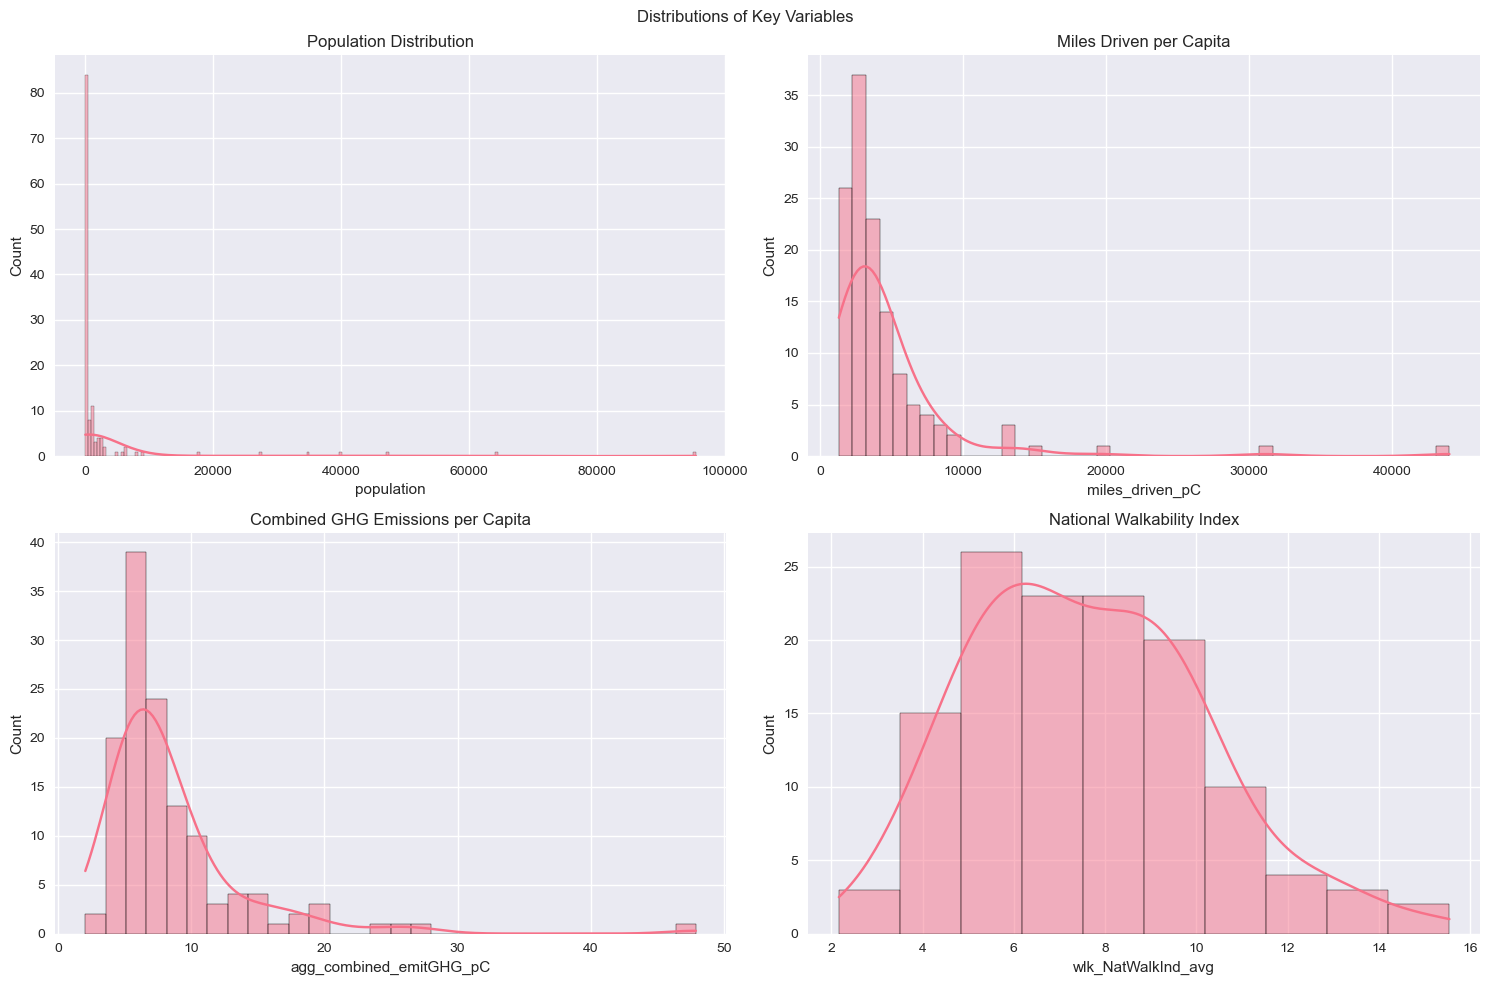

In [16]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distributions of Key Variables')

sns.histplot(df['population'], ax=axes[0,0], kde=True)
axes[0,0].set_title('Population Distribution')

sns.histplot(df['miles_driven_pC'], ax=axes[0,1], kde=True)
axes[0,1].set_title('Miles Driven per Capita')

sns.histplot(df['agg_combined_emitGHG_pC'], ax=axes[1,0], kde=True)
axes[1,0].set_title('Combined GHG Emissions per Capita')

sns.histplot(df['wlk_NatWalkInd_avg'], ax=axes[1,1], kde=True)
axes[1,1].set_title('National Walkability Index')

plt.tight_layout()
plt.savefig('figures/distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

Examine relationships between emissions and walkability.

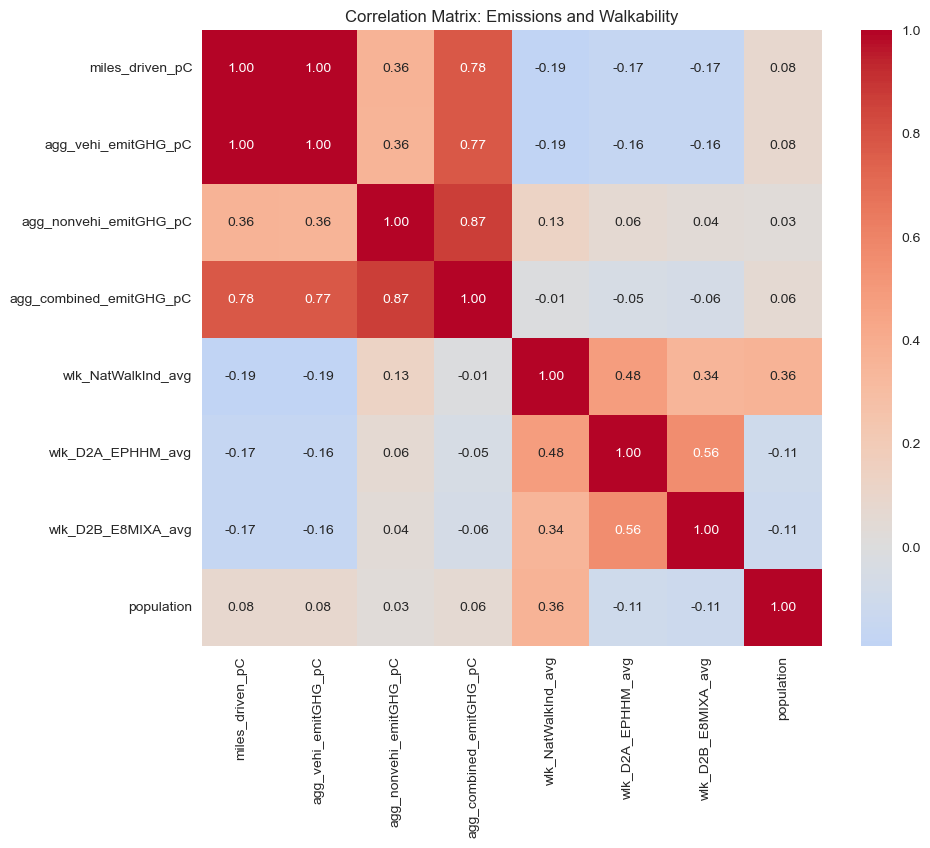

In [17]:
# Select relevant columns for correlation
corr_vars = ['miles_driven_pC', 'agg_vehi_emitGHG_pC', 'agg_nonvehi_emitGHG_pC', 
             'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg', 'wlk_D2A_EPHHM_avg',
             'wlk_D2B_E8MIXA_avg', 'population']

# Correlation matrix
corr_matrix = df[corr_vars].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Emissions and Walkability')
plt.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

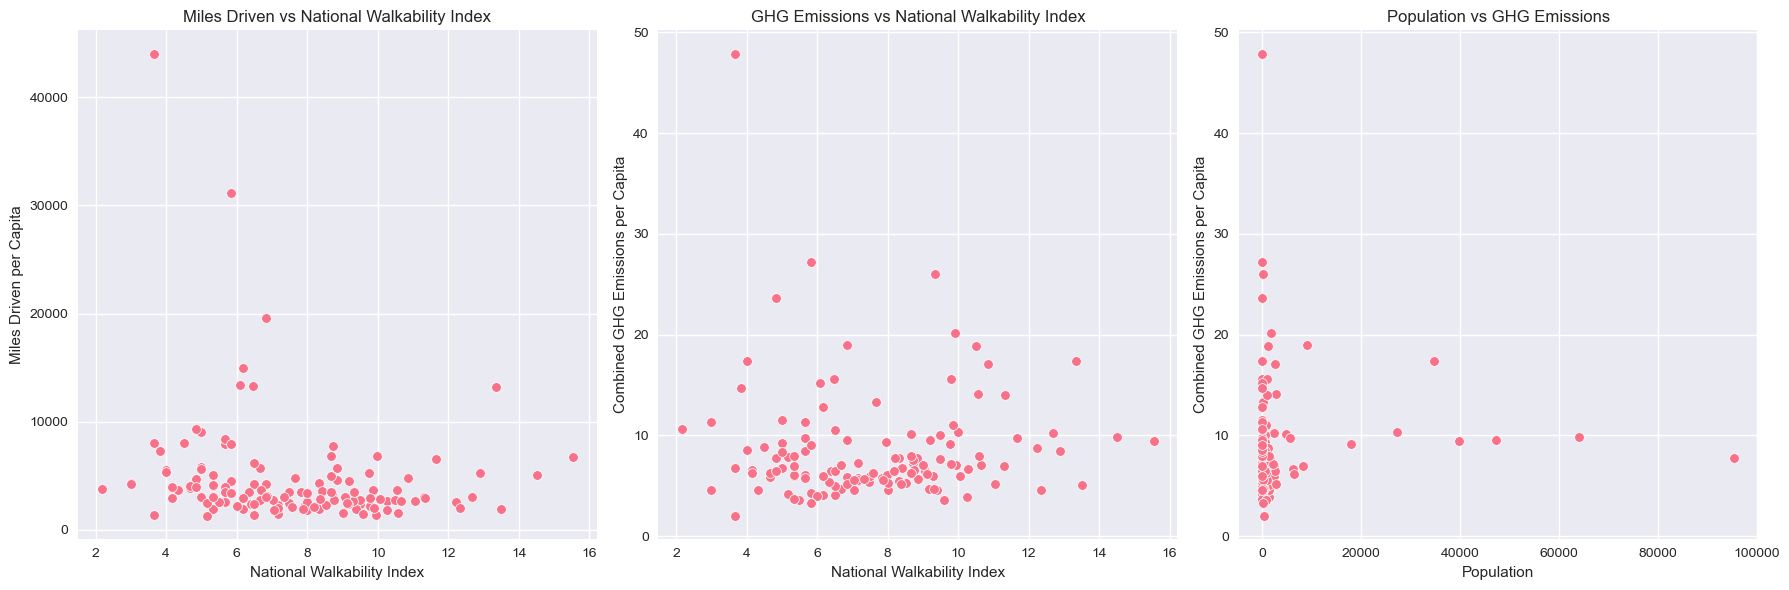

In [18]:
# Scatter plots for key relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Miles driven vs Walkability
sns.scatterplot(data=df, x='wlk_NatWalkInd_avg', y='miles_driven_pC', ax=axes[0])
axes[0].set_title('Miles Driven vs National Walkability Index')
axes[0].set_xlabel('National Walkability Index')
axes[0].set_ylabel('Miles Driven per Capita')

# Emissions vs Walkability
sns.scatterplot(data=df, x='wlk_NatWalkInd_avg', y='agg_combined_emitGHG_pC', ax=axes[1])
axes[1].set_title('GHG Emissions vs National Walkability Index')
axes[1].set_xlabel('National Walkability Index')
axes[1].set_ylabel('Combined GHG Emissions per Capita')

# Population vs Emissions
sns.scatterplot(data=df, x='population', y='agg_combined_emitGHG_pC', ax=axes[2])
axes[2].set_title('Population vs GHG Emissions')
axes[2].set_xlabel('Population')
axes[2].set_ylabel('Combined GHG Emissions per Capita')

plt.tight_layout()
plt.savefig('figures/scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Interactive Visualizations

Create interactive plots for deeper exploration.

In [19]:
# Interactive scatter plot: Emissions vs Walkability
fig = px.scatter(df, x='wlk_NatWalkInd_avg', y='agg_combined_emitGHG_pC', 
                 size='population', color='miles_driven_pC',
                 hover_name='NAME', 
                 title='Interactive: GHG Emissions vs Walkability (Size=Population, Color=Miles Driven)',
                 labels={'wlk_NatWalkInd_avg': 'National Walkability Index',
                        'agg_combined_emitGHG_pC': 'Combined GHG Emissions per Capita',
                        'miles_driven_pC': 'Miles Driven per Capita'})

fig.update_layout(width=800, height=600)
fig.show()

# Save as HTML for sharing
fig.write_html('figures/interactive_emissions_walkability.html')

In [20]:
# Top cities by emissions
top_emissions = df.nlargest(10, 'agg_combined_emitGHG_pC')[['NAME', 'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg', 'population']]

fig = px.bar(top_emissions, x='NAME', y='agg_combined_emitGHG_pC', 
             title='Top 10 Cities by GHG Emissions per Capita',
             labels={'agg_combined_emitGHG_pC': 'GHG Emissions per Capita', 'NAME': 'City'})
fig.update_xaxes(tickangle=45)
fig.show()

# Save
fig.write_html('figures/top_emissions_cities.html')

In [21]:
# Cities with high emissions and low walkability
# Define thresholds
high_emission_threshold = df['agg_combined_emitGHG_pC'].quantile(0.75)
low_walkability_threshold = df['wlk_NatWalkInd_avg'].quantile(0.25)

high_emission_low_walk = df[(df['agg_combined_emitGHG_pC'] > high_emission_threshold) & 
                           (df['wlk_NatWalkInd_avg'] < low_walkability_threshold)]

print(f"Cities with high emissions and low walkability: {len(high_emission_low_walk)}")
high_emission_low_walk[['NAME', 'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg', 'population', 'miles_driven_pC']]

Cities with high emissions and low walkability: 7


,NAME,agg_combined_emitGHG_pC,wlk_NatWalkInd_avg,population,miles_driven_pC
32,Neihart,47.900115,3.666667,3.844160,44023.653846
80,Melstone,17.417170,4.000000,0.514921,5526.858586
113,Sunburst,11.519437,4.998343,2.212473,9016.526502
118,Alberton,23.644161,4.833333,2.203273,9363.832215
119,Denton,11.293645,3.000000,0.676171,4296.213930
122,Outlook,14.712949,3.833333,1.398291,7285.644444
125,Flaxville,10.638363,2.166667,0.027895,3800.904762


## 7. Summary and Conclusions

Based on the analysis:

1. **Key Findings:**
   - Correlation between miles driven and emissions
   - Relationship between walkability and transportation patterns
   - Cities that may benefit from walkability improvements

2. **Recommendations:**
   - Focus on cities with high emissions and low walkability
   - Promote sustainable transportation options
   - Further analysis with additional data

This analysis provides insights into transportation patterns in Montana cities and highlights opportunities for reducing emissions through improved walkability.

In [22]:
# Save processed data
df.to_csv('processed_city_data.csv', index=False)
print("Analysis complete. Processed data saved as 'processed_city_data.csv'")
print("Figures saved in 'figures/' directory")

Analysis complete. Processed data saved as 'processed_city_data.csv'
Figures saved in 'figures/' directory
